<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_12_RSA_to_Compare_GPT_2_and_BERT_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import torch

# Part_1:Embeddings From Two LLms

## Task_1:
- Import the BERT large model and tokenizer, and the GPT-2
medium model and tokenizer. Extract the embeddings matrices from
both models. Use different variable names to avoid confusion or
overwriting (e.g., modelB and modelG).
Print out the sizes of the vocabs and embeddings matrices.

In [1]:

# BERT tokenizer and model
from transformers import BertTokenizer, BertModel

# load BERT tokenizer and model
tokenizerB = BertTokenizer.from_pretrained('bert-large-uncased')
modelB = BertModel.from_pretrained('bert-large-uncased')

# the embeddings matrix
embeddingsB = modelB.embeddings.word_embeddings.weight.detach()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.34GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
# GPT2 tokenizer and model
from transformers import AutoTokenizer,GPT2Model
tokenizerG = AutoTokenizer.from_pretrained('gpt2-medium')
modelG = GPT2Model.from_pretrained('gpt2-medium')

# the embeddings matrix
embeddingsG = modelG.wte.weight.detach()

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.52GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

In [3]:

print(f'BERT vocabulary size: {tokenizerB.vocab_size}')
print(f'GPT2 vocabulary size: {tokenizerG.vocab_size}')
print('')

print(f'BERT embeddings shape: {list(embeddingsB.shape)}')
print(f'GPT2 embeddings shape: {list(embeddingsG.shape)}')

BERT vocabulary size: 30522
GPT2 vocabulary size: 50257

BERT embeddings shape: [30522, 1024]
GPT2 embeddings shape: [50257, 1024]


# Part_2:Compairing Model Embeddings

## Task_1:
- Tokenize each word twice: once with a preceding space and once
without a preceding space. Report the number of tokens in each
encoding for the two models as in the table below (“G” is for GPT,
“B” is for BERT, “-s” means there is a preceding space, and “-n”
means no preceding space).
Store the with-space tokens in two lists (one for the BERT to
kens, one for the GPT-2 tokens). Use those lists to extract
submatrices from the embeddings matrices. Confirm the sizes of the
matrices

In [4]:

# list of words for RSA
words = [ 'space','spaceship','planet','moon'  ,'star' ,'galaxy',
          'chair','table'    ,'couch' ,'stool' ,'floor','desk',
          'apple','banana'   ,'pear'  ,'orange','peach','grape'
        ]

# will be convenient later
num_words = len(words)

# initialize lists of tokens
tokensB = []
tokensG = []

# table header
print('     Word  | B-n | G-n | B-s | G-s')
print('-----------+-----+-----+-----+-----')

for w in words:

  # tokenize without preceding spaces
  tb_nospace = tokenizerB.encode(w,add_special_tokens=False)
  tg_nospace = tokenizerG.encode(w)

  # tokenize with preceding spaces
  tb_withspace = tokenizerB.encode(f' {w}',add_special_tokens=False)
  tg_withspace = tokenizerG.encode(f' {w}')

  # print a row of the table
  print(f'{w:>10} |  {len(tb_nospace)}  |  {len(tg_nospace)}  |  {len(tb_withspace)}  |  {len(tg_withspace)}')

  # add to list
  tokensB.append(tb_nospace[0])
  tokensG.append(tg_withspace[0])

     Word  | B-n | G-n | B-s | G-s
-----------+-----+-----+-----+-----
     space |  1  |  1  |  1  |  1
 spaceship |  1  |  3  |  1  |  1
    planet |  1  |  1  |  1  |  1
      moon |  1  |  1  |  1  |  1
      star |  1  |  1  |  1  |  1
    galaxy |  1  |  2  |  1  |  1
     chair |  1  |  1  |  1  |  1
     table |  1  |  1  |  1  |  1
     couch |  1  |  2  |  1  |  1
     stool |  1  |  2  |  1  |  1
     floor |  1  |  1  |  1  |  1
      desk |  1  |  2  |  1  |  1
     apple |  1  |  1  |  1  |  1
    banana |  1  |  2  |  1  |  1
      pear |  1  |  2  |  1  |  1
    orange |  1  |  1  |  1  |  1
     peach |  1  |  2  |  1  |  1
     grape |  1  |  2  |  1  |  1


In [5]:
tokensB,tokensG

([2686,
  25516,
  4774,
  4231,
  2732,
  9088,
  3242,
  2795,
  6411,
  14708,
  2723,
  4624,
  6207,
  15212,
  28253,
  4589,
  18237,
  14722],
 [2272,
  40663,
  5440,
  8824,
  3491,
  16161,
  5118,
  3084,
  18507,
  38753,
  4314,
  6915,
  17180,
  25996,
  25286,
  10912,
  47565,
  30777])

## Task_2:
- Calculate the correlation coefficient between the BERT and GPT-2
embeddings for each word. Show one example word in a scatter
plot and the rest of the correlations in a second plot, as in Figure 3.21.
Think about what the analysis and results mean, and what
conclusions you can draw. Also think about why I asked for the
correlation coefficient and not cosine similarity.

In [6]:
# embeddings matrix for these words
sub_embedB = embeddingsB[tokensB,:]
sub_embedG = embeddingsG[tokensG,:]

print(f'BERT embeddings shape: {list(sub_embedB.shape)}')
print(f'GPT2 embeddings shape: {list(sub_embedG.shape)}')

BERT embeddings shape: [18, 1024]
GPT2 embeddings shape: [18, 1024]


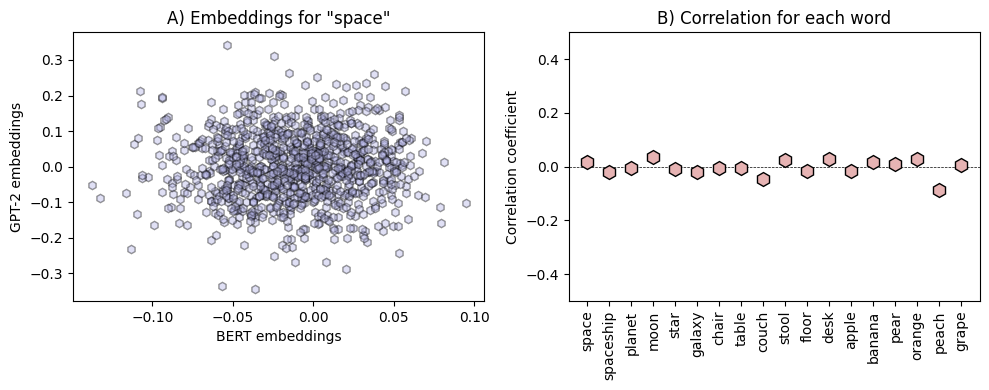

In [9]:

_,axs = plt.subplots(1,2,figsize=(10,4))

# scatter plot of an example word
axs[0].plot(sub_embedB[0,:],sub_embedG[0,:],'kh',
            markerfacecolor=[.7,.7,.9,.4])
axs[0].set(xlabel='BERT embeddings',ylabel='GPT-2 embeddings',title=f'A) Embeddings for "{words[0]}"')

# correlations for all words
for i in range(num_words):
  r = np.corrcoef(sub_embedB[i,:],sub_embedG[i,:])[0,1]
  axs[1].plot(i,r,'kh',markerfacecolor=[.9,.7,.7],markersize=10)

axs[1].axhline(0,linestyle='--',color='k',linewidth=.5,zorder=-1)
axs[1].set(xticks=range(num_words),xticklabels=words,ylim=[-.5,.5],
           title='B) Correlation for each word',ylabel='Correlation coefficient')
axs[1].tick_params(axis='x',labelrotation=90)

plt.tight_layout()

plt.show()

# Part_3:Representational Similarity Analysis

## Task_1:
- Perform and visualize an RSA. First, calculate the cosine similarity
between all pairs of embeddings vectors within each model. That
will produce two 18 × 18 cosine similarity matrices, and you can
visualize them as heatmaps as in Figure 3.22A-B.
Second, extract the 153 non-redundant elements in each ma
trix (e.g., from the upper-triangle excluding the main diagonal).
Third, make a scatter plot of the cosine similarities from BERT and
GPT-2 and visualize as in Figure 3.22C. Finally, calculate the RSA
score as the correlation coefficient between the cosine similarities,
and print in the title of the scatter plot.
Explain why the RSA score is a correlation coefficient instead
of a cosine similarity score

In [10]:
# cosine similarities
csG = torch.zeros((num_words,num_words))
csB = torch.zeros((num_words,num_words))

for i in range(num_words):
  csB[i,:] = torch.cosine_similarity(sub_embedB[i],sub_embedB)
  csG[i,:] = torch.cosine_similarity(sub_embedG[i],sub_embedG)


# extract the upper-triangular elements
unique_B = csB[np.triu_indices_from(csB, k=1)]
unique_G = csG[np.triu_indices_from(csG, k=1)]

# Pearson correlation
r = np.corrcoef(unique_B,unique_G)[0,1]

print(f'Size of similarity matrices: {csB.shape}')
print(f'Number of non-redundant elements: {len(unique_B)}')

Size of similarity matrices: torch.Size([18, 18])
Number of non-redundant elements: 153


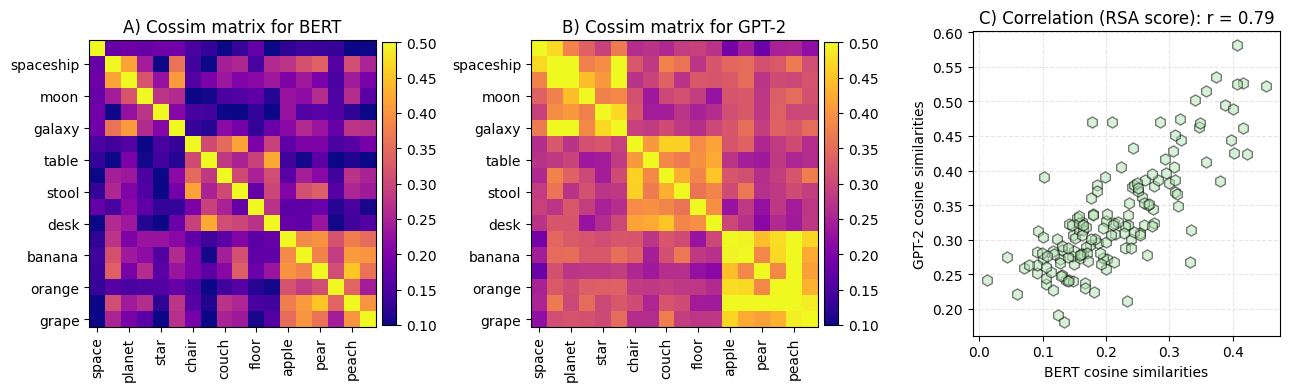

In [11]:
# and visualize
fig,axs = plt.subplots(1,3,figsize=(13,4))

# color limits for images
vminmax = [.1,.5]

# BERT: cosine similarity matrix
h = axs[0].imshow(csB,vmin=vminmax[0],vmax=vminmax[1],cmap='plasma')
axs[0].set(xticks=range(0,len(words),2),xticklabels=words[::2],
           yticks=range(1,len(words),2),yticklabels=words[1::2],
           title='A) Cossim matrix for BERT')
axs[0].tick_params(axis='x',labelrotation=90)
fig.colorbar(h,ax=axs[0],fraction=.046,pad=.02)


# GPT2: cosine similarity matrix
h = axs[1].imshow(csG,vmin=vminmax[0],vmax=vminmax[1],cmap='plasma')
axs[1].set(xticks=range(0,len(words),2),xticklabels=words[::2],
           yticks=range(1,len(words),2),yticklabels=words[1::2],
           title='B) Cossim matrix for GPT-2')
axs[1].tick_params(axis='x',labelrotation=90)
fig.colorbar(h,ax=axs[1],fraction=.046,pad=.02)


# scatter plot
axs[2].plot(unique_B,unique_G,'kh',markersize=8,markerfacecolor=[.7,.9,.7,.5])
axs[2].set(xlabel='BERT cosine similarities',ylabel='GPT-2 cosine similarities',
              title=f'C) Correlation (RSA score): r = {r:.2f}')
axs[2].grid(linestyle='--',color=[.9,.9,.9])


plt.tight_layout()
